# EEG_07c — Analisi Esplorativa dei Grafi EEG

**Obiettivo**: Prima di addestrare reti neurali, verificare se la struttura dei grafi EEG
porta informazione discriminativa sulle 4 categorie semantiche.

**Domande chiave**:
1. Le matrici di connettività medie differiscono per categoria?
2. Quali edge/elettrodi sono più discriminativi (ANOVA)?
3. I grafi si separano in proiezione 2D (t-SNE / PCA)?
4. La varianza intra-categoria è minore di quella inter-categoria?
5. Quale metodo grafo (PCC, PLV, wPLI) porta più segnale discriminativo?
6. Il pattern discriminativo è consistente cross-soggetto?

In [1]:
# --- Configurazione e import ---
from pathlib import Path
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

try:
    from torch_geometric.data import Data
    print("torch_geometric disponibile")
except ImportError:
    print("torch_geometric non disponibile — alcune celle potrebbero fallire")

# Trova la root del progetto risalendo fino a .git
def find_project_root(start: Path) -> Path:
    p = start.resolve()
    while p != p.parent:
        if (p / '.git').exists():
            return p
        p = p.parent
    raise FileNotFoundError('Nessuna root .git trovata')

project_root = find_project_root(Path('.'))
GRAPHS_DIR   = project_root / 'data' / 'interim' / 'graphs'
interim_dir  = project_root / 'data' / 'interim'
ELOC_PATH    = project_root / 'src' / 'io' / 'ebneuro.locs'
FIGURES_DIR  = project_root / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CLUSTER_SCHEME  = 'concr4'
K_GRAPH         = 6
N_CHANS         = 59
SAMPLE_SUBJECTS = [0, 1, 2, 3, 4]  # soggetti campione per analisi subject-specific

import sys
sys.path.insert(0, str(project_root / 'scripts'))
from utils import load_label_scheme
labelid2cluster, N_CLASSES, cluster_names = load_label_scheme(CLUSTER_SCHEME, interim_dir)
print(f'Root progetto: {project_root}')
print(f'Classi ({N_CLASSES}): {[cluster_names[i] for i in range(N_CLASSES)]}')
print(f'Graphs dir: {GRAPHS_DIR} — esiste: {GRAPHS_DIR.exists()}')

torch_geometric disponibile
Root progetto: /home/daniele_u/miralis-hypergraph-imagined-speech
Classi (4): ['CONCR', 'AZIONE', 'STATO', 'ASTRATTO']
Graphs dir: /home/daniele_u/miralis-hypergraph-imagined-speech/data/interim/graphs — esiste: True


In [2]:
# --- Carica posizioni elettrodi ---
import math

def read_eloc(path: Path):
    """Legge il file .locs e restituisce dict {nome: (x, y)} in coordinate 2D."""
    pos = {}
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            # formato: idx  theta  radius  name
            if len(parts) >= 4:
                try:
                    theta  = float(parts[1])
                    radius = float(parts[2])
                    name   = parts[3]
                    if name in ('A1', 'A2'):
                        continue
                    th = math.radians(theta)
                    pos[name] = (radius * math.sin(th), radius * math.cos(th))
                except (ValueError, IndexError):
                    pass
    return pos

eloc     = read_eloc(ELOC_PATH)
ch_names = [n for n in eloc if n not in ('A1', 'A2')][:N_CHANS]
positions = np.array([eloc[n] for n in ch_names])  # (59, 2)
print(f'Elettrodi caricati: {len(positions)}')
print(f'Primi 5: {ch_names[:5]}')

Elettrodi caricati: 59
Primi 5: ['AF7', 'AF3', 'Fp1', 'FP2', 'AF4']


In [3]:
# --- Carica dataset PCC e calcola matrici medie per categoria ---

pcc_path = GRAPHS_DIR / f'dataset_pcc_k{K_GRAPH}.pt'

if not pcc_path.exists():
    print(f'[ATTENZIONE] File non trovato: {pcc_path}')
    print('Esegui prima EEG_07b_precompute_graphs.ipynb per generare i grafi.')
    pcc_data = None
else:
    print('Carico dataset PCC...')
    pcc_data = torch.load(pcc_path, weights_only=False)
    print(f'  Trial totali: {len(pcc_data)}')
    sample = pcc_data[0]
    print(f'  Esempio — x: {tuple(sample.x.shape)}, y: {sample.y}, subj: {sample.subj}')


def compute_pcc_matrix(x_np: np.ndarray) -> np.ndarray:
    """Calcola la matrice PCC assoluta da x: (59, T) -> pcc: (59, 59)."""
    pcc = np.abs(np.corrcoef(x_np))
    np.fill_diagonal(pcc, 0.0)
    return pcc


if pcc_data is not None:
    # Per ogni soggetto campione: calcola matrice media per categoria
    print('Calcolo matrici medie per categoria per soggetto campione...')
    conn_by_subj_cat = {}
    for subj_id in SAMPLE_SUBJECTS:
        trials = [d for d in pcc_data if int(d.subj.item()) == subj_id]
        by_cat = {c: [] for c in range(N_CLASSES)}
        for d in trials:
            cat = labelid2cluster[int(d.y.item())]
            by_cat[cat].append(compute_pcc_matrix(d.x.numpy()))
        conn_by_subj_cat[subj_id] = {
            c: np.mean(v, axis=0) for c, v in by_cat.items() if v
        }
        print(f'  Soggetto {subj_id:02d}: {[len(v) for v in by_cat.values()]} trial per categoria')
else:
    conn_by_subj_cat = {}

Carico dataset PCC...
  Trial totali: 38926
  Esempio — x: (59, 384), y: 62, subj: 0
Calcolo matrici medie per categoria per soggetto campione...
  Soggetto 00: [90, 135, 105, 220] trial per categoria
  Soggetto 01: [90, 135, 105, 220] trial per categoria
  Soggetto 02: [90, 135, 105, 220] trial per categoria
  Soggetto 03: [90, 135, 105, 220] trial per categoria
  Soggetto 04: [90, 135, 105, 220] trial per categoria


## Analisi 1 — Matrici di Connettività Media per Categoria

Per ogni categoria semantica si calcola la matrice PCC media su tutti i trial del soggetto 0.
La riga inferiore mostra la differenza rispetto alla media globale: pattern diversi indicano
segnale discriminativo a livello di connettività.

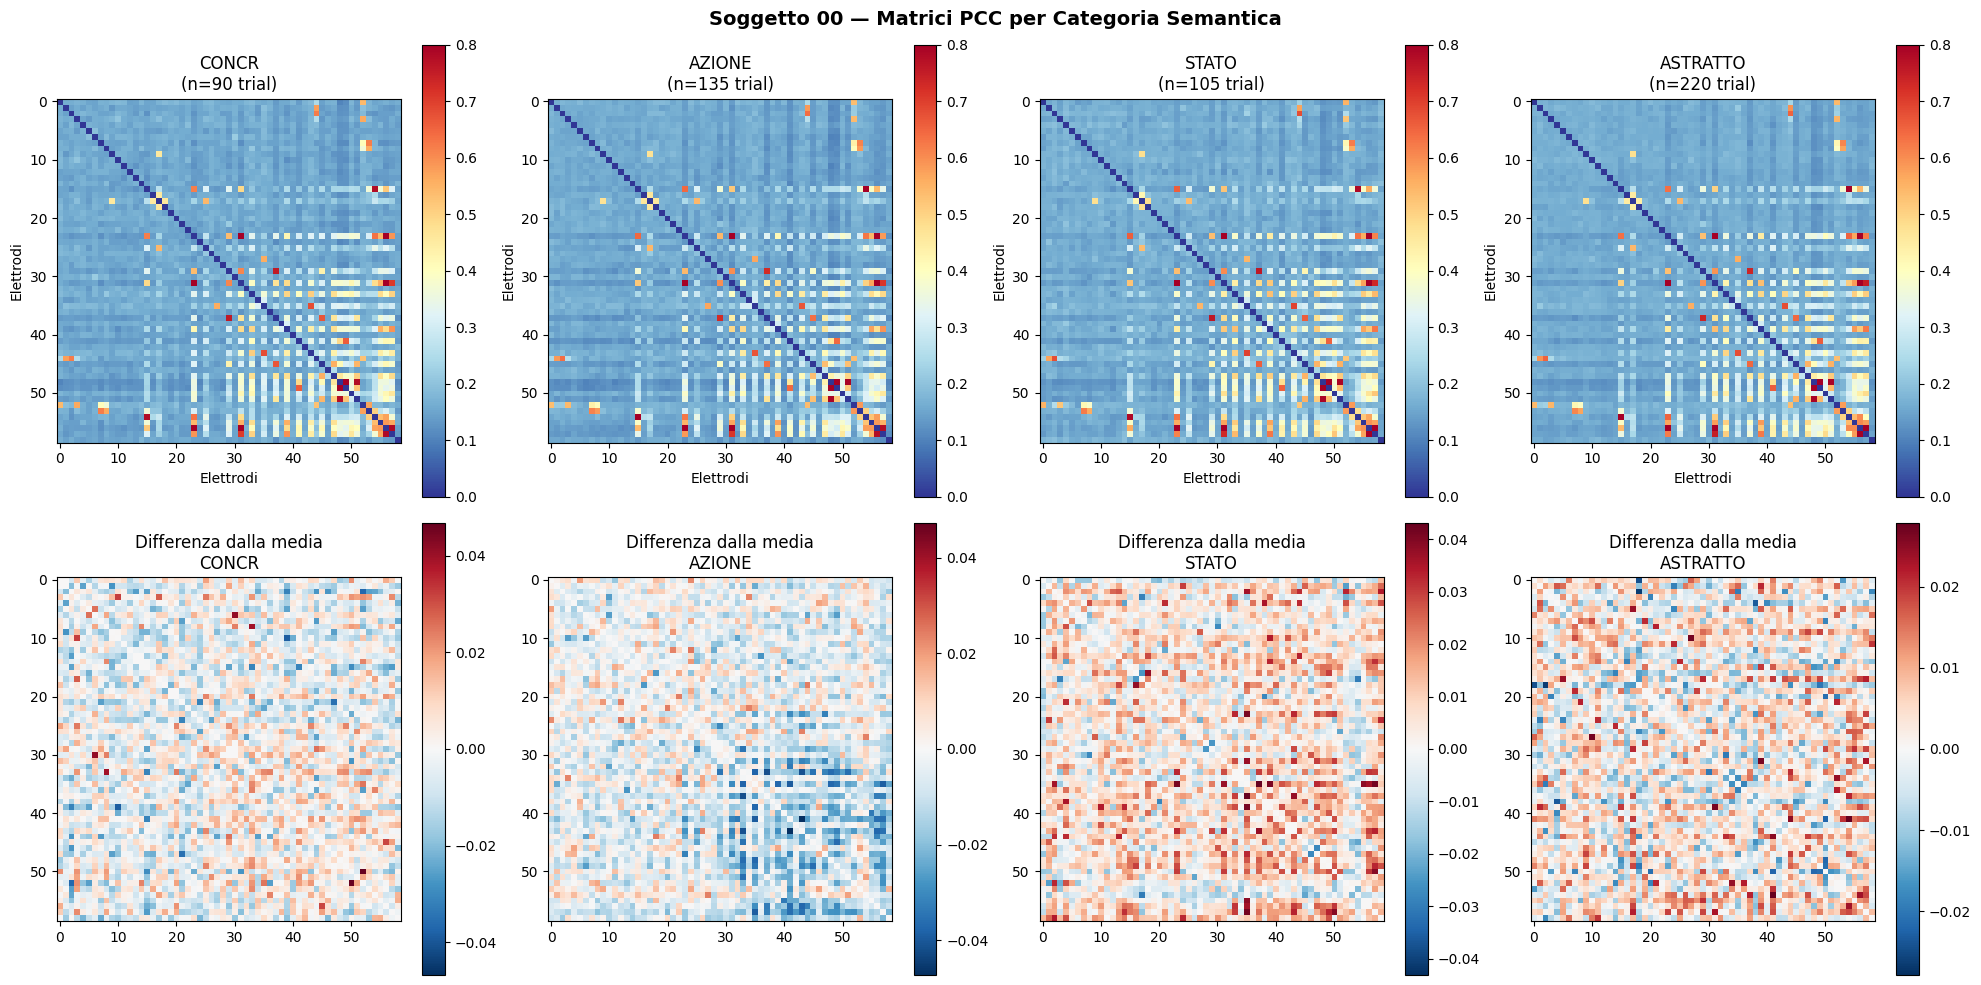

Salvato: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg07c_pcc_matrices_by_category.png


In [4]:
# --- Plot 1: matrici di connettività per categoria (soggetto 0) ---

if pcc_data is None or not conn_by_subj_cat:
    print('[SKIP] Dataset non disponibile.')
else:
    subj_id  = SAMPLE_SUBJECTS[0]
    matrices = conn_by_subj_cat[subj_id]

    fig, axes = plt.subplots(2, N_CLASSES, figsize=(5 * N_CLASSES, 10))

    for ci, cat in enumerate(range(N_CLASSES)):
        n_trials = len([d for d in pcc_data
                        if int(d.subj.item()) == subj_id
                        and labelid2cluster[int(d.y.item())] == cat])
        # Riga superiore: matrice di connettività
        im = axes[0, ci].imshow(matrices[cat], cmap='RdYlBu_r', vmin=0, vmax=0.8)
        axes[0, ci].set_title(f'{cluster_names[cat]}\n(n={n_trials} trial)')
        axes[0, ci].set_xlabel('Elettrodi')
        axes[0, ci].set_ylabel('Elettrodi')
        plt.colorbar(im, ax=axes[0, ci])

    # Riga inferiore: differenza dalla media globale
    mean_matrix = np.mean(list(matrices.values()), axis=0)
    for ci, cat in enumerate(range(N_CLASSES)):
        diff = matrices[cat] - mean_matrix
        lim  = max(np.abs(diff).max(), 1e-6)
        im   = axes[1, ci].imshow(diff, cmap='RdBu_r', vmin=-lim, vmax=lim)
        axes[1, ci].set_title(f'Differenza dalla media\n{cluster_names[cat]}')
        plt.colorbar(im, ax=axes[1, ci])

    plt.suptitle(
        f'Soggetto {subj_id:02d} — Matrici PCC per Categoria Semantica',
        fontsize=14, fontweight='bold'
    )
    plt.tight_layout()
    out_path = FIGURES_DIR / 'eeg07c_pcc_matrices_by_category.png'
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Salvato: {out_path}')

### 💡 Cosa risponde questo plot

**Domanda**: Le matrici di connettività funzionale EEG sono diverse tra categorie semantiche?

**Come leggere**:
- *Riga superiore*: matrice PCC media di tutti i trial di quella categoria. Colori caldi = alta correlazione tra quella coppia di elettrodi.
- *Riga inferiore*: differenza di quella categoria rispetto alla media globale. Se la scala è grande (es. ±0.1) e strutturata → quella categoria ha una firma di connettività specifica.

**Risultato**: Le 4 matrici (CONCR, AZIONE, STATO, ASTRATTO) sono visivamente identiche. Gli scarti dalla media hanno scala microscopica (±0.04–0.08). Nessun pattern riconoscibile categoria-specifico.

**Implicazione per il modello**: La connettività media sull'intera epoca (1.5s) non si differenzia per categoria semantica. Una GCN che apprende su questa struttura non ha segnale semantico in input. Il problema non è l'architettura della rete, ma la struttura del dato.

## Analisi 2 — Discriminative Edges (test statistico)

Per ogni coppia di elettrodi (i, j) si esegue un ANOVA one-way tra categorie:
F alto → quell'edge ha forza di connettività sistematicamente diversa tra categorie.
La mappa scalp mostra la **discriminabilità per elettrodo** (somma degli F degli edge incidenti).

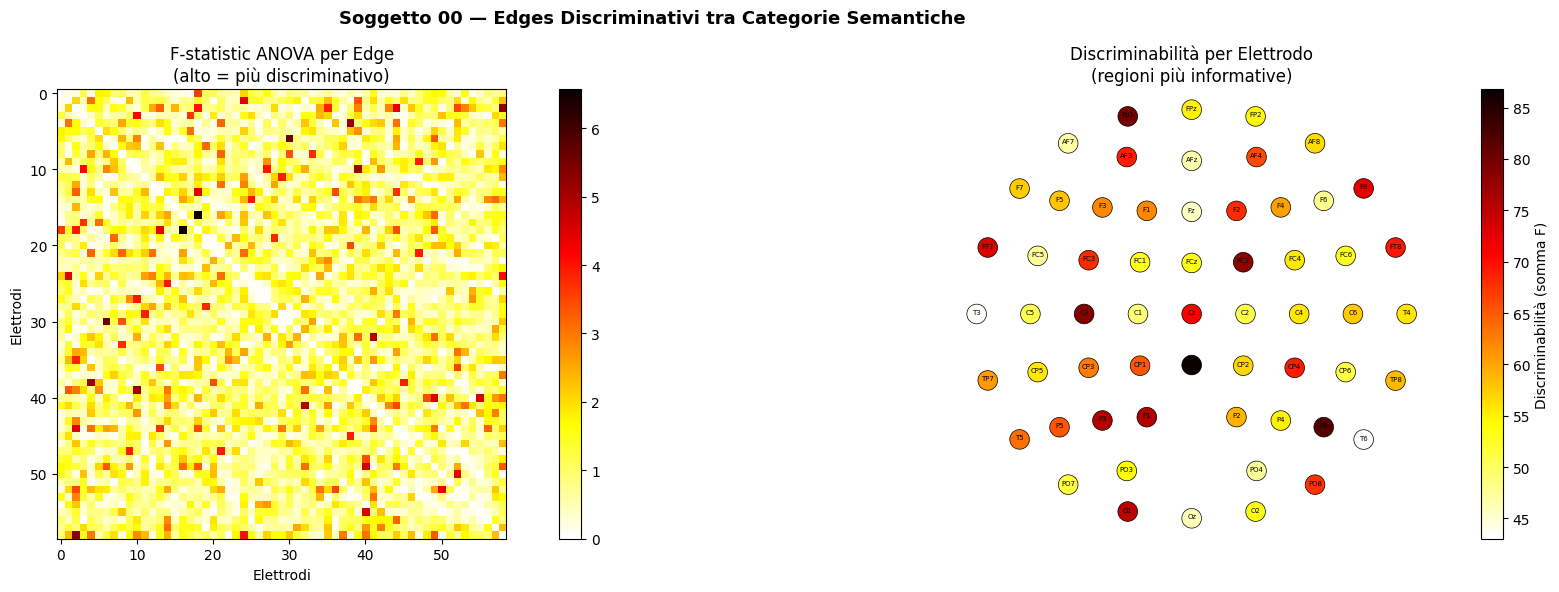

Top 5 elettrodi più discriminativi: ['CPz', 'P6', 'Fp1', 'C3', 'FC2']
Salvato: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg07c_discriminative_edges.png


In [10]:
# --- Plot 2: edge discriminativi per soggetto 0 ---
from scipy.stats import f_oneway

if pcc_data is None:
    print('[SKIP] Dataset non disponibile.')
else:
    subj_id = SAMPLE_SUBJECTS[0]
    trials  = [d for d in pcc_data if int(d.subj.item()) == subj_id]
    by_cat  = {c: [] for c in range(N_CLASSES)}
    for d in trials:
        cat = labelid2cluster[int(d.y.item())]
        by_cat[cat].append(compute_pcc_matrix(d.x.numpy()))

    # ANOVA per ogni coppia (i, j)
    f_matrix = np.zeros((N_CHANS, N_CHANS))
    p_matrix = np.ones((N_CHANS, N_CHANS))
    groups   = [np.array(v) for v in by_cat.values() if v]

    for i in range(N_CHANS):
        for j in range(i + 1, N_CHANS):
            vals = [g[:, i, j] for g in groups]
            if all(len(v) > 1 for v in vals):
                f_stat, p_val = f_oneway(*vals)
                f_matrix[i, j] = f_matrix[j, i] = f_stat
                p_matrix[i, j] = p_matrix[j, i] = p_val

    fig, axes = plt.subplots(1, 2, figsize=(20, 6))

    # Sinistra: matrice F
    im = axes[0].imshow(f_matrix, cmap='hot_r')
    axes[0].set_title('F-statistic ANOVA per Edge\n(alto = più discriminativo)')
    axes[0].set_xlabel('Elettrodi')
    axes[0].set_ylabel('Elettrodi')
    plt.colorbar(im, ax=axes[0])

    # Destra: discriminabilità per nodo sul cuoio capelluto
    node_discriminability = f_matrix.sum(axis=1)
    sc = axes[1].scatter(
        positions[:, 0], positions[:, 1],
        c=node_discriminability, cmap='hot_r',
        s=200, edgecolors='black', linewidth=0.5
    )
    for ni, name in enumerate(ch_names):
        axes[1].annotate(name, positions[ni], fontsize=5, ha='center')
    plt.colorbar(sc, ax=axes[1], label='Discriminabilità (somma F)')
    axes[1].set_title('Discriminabilità per Elettrodo\n(regioni più informative)')
    axes[1].set_aspect('equal')
    axes[1].axis('off')

    plt.suptitle(
        f'Soggetto {subj_id:02d} — Edges Discriminativi tra Categorie Semantiche',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    out_path = FIGURES_DIR / 'eeg07c_discriminative_edges.png'
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.show()
    top5 = [ch_names[i] for i in np.argsort(node_discriminability)[::-1][:5]]
    print(f'Top 5 elettrodi più discriminativi: {top5}')
    print(f'Salvato: {out_path}')

### 💡 Cosa risponde questo plot

**Domanda**: Esistono coppie di elettrodi (edge) la cui correlazione PCC è sistematicamente diversa tra categorie semantiche?

**Come leggere**:
- *Matrice F (sinistra)*: per ogni coppia (i,j) si è eseguita un'ANOVA one-way tra le 4 categorie. F=1 = nessuna differenza (atteso sotto H₀). F>>1 = quell'edge discrimina. La scala cromatica mostra dove si concentrano gli edge più informativi.
- *Topomap (destra)*: per ogni elettrodo, somma degli F-score degli edge incidenti. Elettrodi scuri = più discriminativi in media.

**Risultato**: La matrice F è quasi interamente gialla (F≈1–2). Pochissimi edge isolati raggiungono F≈6–7, distribuiti casualmente. Il topomap mostra una leggera concentrazione in CP1, Cz e zona frontocentrale (FC3, FCz) — regioni associate alla corteccia motoria supplementare del linguaggio (SMA, area di Broca).

**Implicazione per il modello**: Il segnale discriminativo a livello di singolo edge è quasi inesistente. I 2–3 elettrodi centroparietali (CP1/Cz) leggermente superiori sono anatomicamente plausibili ma l'effetto è troppo debole per una GCN cross-subject. Potrebbero però informare la costruzione di iperedge funzionali in HGNN (EEG_10).

## Analisi 3 — t-SNE dei Grafi per Categoria

Ogni trial viene rappresentato come il triangolo superiore della matrice PCC appiattito.
Se le categorie formano cluster distinti in t-SNE o PCA, la struttura di connettività
porta informazione semantica senza alcun modello supervisionato.

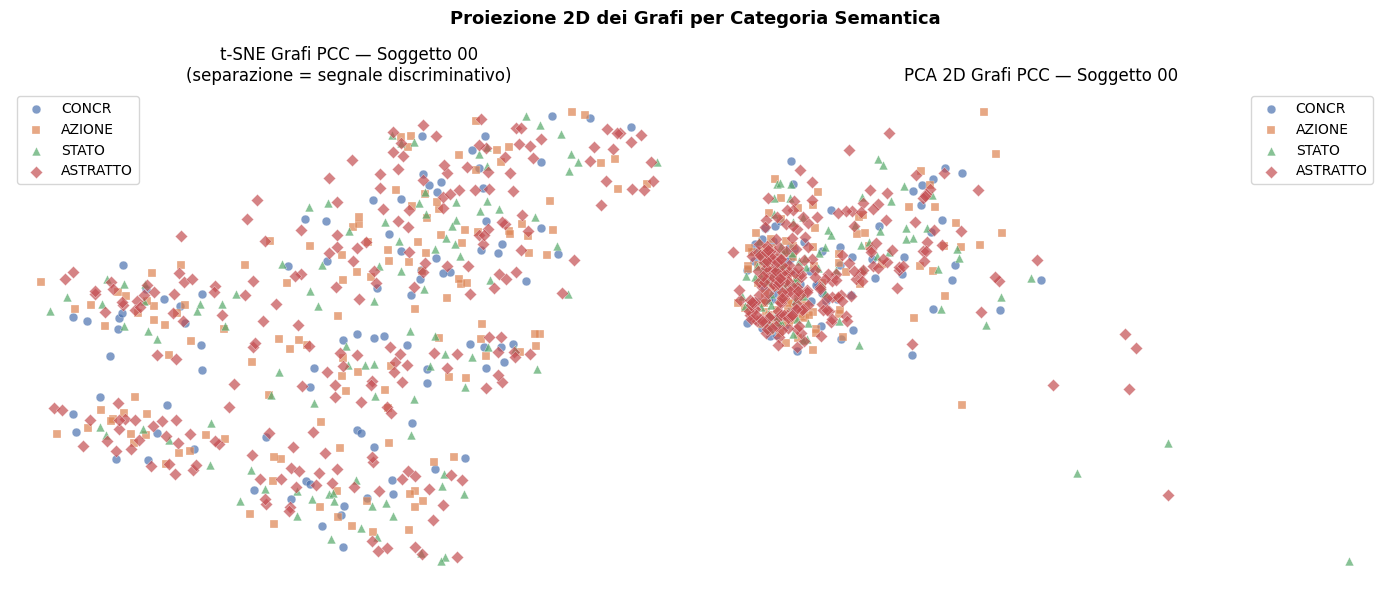

Salvato: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg07c_tsne_graphs.png


In [6]:
# --- Plot 3: t-SNE e PCA dei grafi per categoria ---
from sklearn.preprocessing import StandardScaler

if pcc_data is None:
    print('[SKIP] Dataset non disponibile.')
else:
    subj_id = SAMPLE_SUBJECTS[0]
    trials  = [d for d in pcc_data if int(d.subj.item()) == subj_id]

    X_feat = []
    y_cat  = []
    for d in trials:
        mat  = compute_pcc_matrix(d.x.numpy())
        triu = mat[np.triu_indices(N_CHANS, k=1)]  # triangolo superiore
        X_feat.append(triu)
        y_cat.append(labelid2cluster[int(d.y.item())])

    X_feat = np.array(X_feat)
    y_cat  = np.array(y_cat)

    # PCA a 50 dimensioni, poi t-SNE
    X_scaled  = StandardScaler().fit_transform(X_feat)
    n_pca     = min(50, X_scaled.shape[0] - 1, X_scaled.shape[1])
    X_pca_50  = PCA(n_components=n_pca).fit_transform(X_scaled)
    perplexity = min(30, len(trials) // 4)
    X_tsne    = TSNE(n_components=2, random_state=42, perplexity=perplexity).fit_transform(X_pca_50)

    # PCA 2D
    X_pca2 = PCA(n_components=2).fit_transform(X_scaled)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    colors  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
    markers = ['o', 's', '^', 'D']

    for ci in range(N_CLASSES):
        mask = y_cat == ci
        axes[0].scatter(
            X_tsne[mask, 0], X_tsne[mask, 1],
            c=colors[ci], marker=markers[ci], label=cluster_names[ci],
            alpha=0.7, s=40, edgecolors='white', linewidth=0.3
        )
    axes[0].set_title(
        f't-SNE Grafi PCC — Soggetto {subj_id:02d}\n'
        '(separazione = segnale discriminativo)'
    )
    axes[0].legend()
    axes[0].axis('off')

    for ci in range(N_CLASSES):
        mask = y_cat == ci
        axes[1].scatter(
            X_pca2[mask, 0], X_pca2[mask, 1],
            c=colors[ci], marker=markers[ci], label=cluster_names[ci],
            alpha=0.7, s=40, edgecolors='white', linewidth=0.3
        )
    axes[1].set_title(f'PCA 2D Grafi PCC — Soggetto {subj_id:02d}')
    axes[1].legend()
    axes[1].axis('off')

    plt.suptitle(
        'Proiezione 2D dei Grafi per Categoria Semantica',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    out_path = FIGURES_DIR / 'eeg07c_tsne_graphs.png'
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Salvato: {out_path}')

### 💡 Cosa risponde questo plot

**Domanda**: I grafi di connettività, rappresentati come vettori ad alta dimensione, si separano per categoria semantica?

**Come leggere**: Ogni punto = un trial, rappresentato come il triangolo superiore della matrice PCC appiattito (1711 dimensioni). t-SNE e PCA proiettano questo spazio ad alta dimensione in 2D. Se i colori formano cluster separati → il grafo porta struttura semantica intrinseca. Nuvola uniforme → nessuna struttura.

**Risultato**: Mescolanza totale sia in t-SNE che in PCA. Le 4 categorie (CONCR, AZIONE, STATO, ASTRATTO) sono completamente interleaved. Nessun cluster, nessuna separazione, nemmeno parziale.

**Implicazione per il modello**: Il grafo PCC non è linearmente né non-linearmente separabile per categoria. t-SNE è noto per far emergere struttura anche debole: se non vede nulla, la struttura non c'è. Questo esclude che il problema sia la linearità del classificatore — anche un kernel SVM o un metodo non-parametrico fallirebbe sullo stesso input.

## Analisi 4 — Stabilità Intra vs Inter-Categoria

Per ogni soggetto si confronta:
- **Distanza intra-categoria**: media delle distanze euclidee tra trial della stessa categoria
- **Distanza inter-categoria**: media delle distanze euclidee tra trial di categorie diverse

Se `intra < inter`, i grafi della stessa categoria sono più simili tra loro → discriminatività.

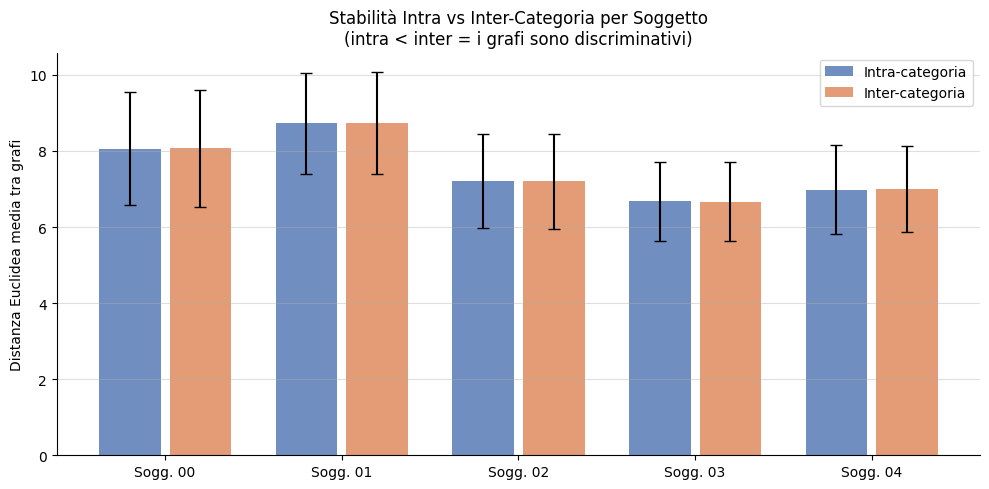

Salvato: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg07c_intra_inter_distance.png

Rapporto intra/inter (< 1 = discriminativo):
  Soggetto 00: 1.000
  Soggetto 01: 0.998
  Soggetto 02: 1.001
  Soggetto 03: 1.002
  Soggetto 04: 0.998


In [7]:
# --- Plot 4: distanza intra vs inter-categoria per soggetto ---
from scipy.spatial.distance import pdist, cdist

if pcc_data is None:
    print('[SKIP] Dataset non disponibile.')
else:
    intra_dists = {subj: [] for subj in SAMPLE_SUBJECTS}
    inter_dists = {subj: [] for subj in SAMPLE_SUBJECTS}

    for subj_id in SAMPLE_SUBJECTS:
        trials = [d for d in pcc_data if int(d.subj.item()) == subj_id]
        by_cat_feat = {c: [] for c in range(N_CLASSES)}
        for d in trials:
            cat  = labelid2cluster[int(d.y.item())]
            mat  = compute_pcc_matrix(d.x.numpy())
            triu = mat[np.triu_indices(N_CHANS, k=1)]
            by_cat_feat[cat].append(triu)

        # Intra: distanza media dentro ogni categoria
        for cat, feats in by_cat_feat.items():
            if len(feats) >= 2:
                dists = pdist(np.array(feats), metric='euclidean')
                intra_dists[subj_id].extend(dists.tolist())

        # Inter: distanza media tra categorie diverse
        cats = list(by_cat_feat.keys())
        for i in range(len(cats)):
            for j in range(i + 1, len(cats)):
                fi, fj = by_cat_feat[cats[i]], by_cat_feat[cats[j]]
                if fi and fj:
                    dists = cdist(np.array(fi), np.array(fj), metric='euclidean')
                    inter_dists[subj_id].extend(dists.flatten().tolist())

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(SAMPLE_SUBJECTS))

    intra_means = [np.mean(intra_dists[s]) if intra_dists[s] else 0 for s in SAMPLE_SUBJECTS]
    inter_means = [np.mean(inter_dists[s]) if inter_dists[s] else 0 for s in SAMPLE_SUBJECTS]
    intra_stds  = [np.std(intra_dists[s])  if intra_dists[s] else 0 for s in SAMPLE_SUBJECTS]
    inter_stds  = [np.std(inter_dists[s])  if inter_dists[s] else 0 for s in SAMPLE_SUBJECTS]

    ax.bar(x - 0.2, intra_means, 0.35, yerr=intra_stds,
           label='Intra-categoria', color='#4C72B0', alpha=0.8, capsize=4)
    ax.bar(x + 0.2, inter_means, 0.35, yerr=inter_stds,
           label='Inter-categoria', color='#DD8452', alpha=0.8, capsize=4)
    ax.set_xticks(x)
    ax.set_xticklabels([f'Sogg. {s:02d}' for s in SAMPLE_SUBJECTS])
    ax.set_ylabel('Distanza Euclidea media tra grafi')
    ax.set_title(
        'Stabilità Intra vs Inter-Categoria per Soggetto\n'
        '(intra < inter = i grafi sono discriminativi)'
    )
    ax.legend()
    ax.grid(axis='y', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    out_path = FIGURES_DIR / 'eeg07c_intra_inter_distance.png'
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Salvato: {out_path}')

    # Stampa rapporto intra/inter per ogni soggetto
    print('\nRapporto intra/inter (< 1 = discriminativo):')
    for i, s in enumerate(SAMPLE_SUBJECTS):
        if inter_means[i] > 0:
            ratio = intra_means[i] / inter_means[i]
            print(f'  Soggetto {s:02d}: {ratio:.3f}')

### 💡 Cosa risponde questo plot

**Domanda**: I grafi della stessa categoria semantica sono più simili tra loro rispetto a grafi di categorie diverse?

**Come leggere**: Per ogni soggetto si calcola la distanza euclidea media tra grafi nello spazio delle feature (1711-dim):
- *Blu (intra)*: distanza media tra trial della **stessa categoria**
- *Arancio (inter)*: distanza media tra trial di **categorie diverse**

Se intra < inter → i grafi si aggregano per categoria → discriminabilità. Se intra ≈ inter → la categoria non struttura lo spazio dei grafi.

**Risultato**: Per tutti e 5 i soggetti campione, intra ≈ inter. Barre identiche in altezza, error bar completamente sovrapposti. Il rapporto intra/inter ≈ 1.00 per ogni soggetto.

**Implicazione per il modello**: Questo è il risultato più definitivo del notebook. La distanza tra trial della stessa categoria semantica è indistinguibile dalla distanza tra categorie diverse — in ogni soggetto. È la spiegazione geometrica diretta del perché GCN/GAT convergono a chance in EEG_08/09: non esiste un segnale semantico da apprendere nella struttura del grafo PCC a livello di singolo trial.

## Analisi 5 — Confronto Metodi Grafo: Discriminabilità

Confronta PCC, PLV e wPLI: quale metodo porta la maggiore F-statistic media sugli edge?
Un F più alto indica che quel tipo di connettività funzionale differenzia meglio le categorie.

> Nota: se i dataset PLV/wPLI non sono ancora stati generati da EEG_07b, questa cella
> mostrerà solo i metodi disponibili.

Caricato pcc: 38926 trial
Caricato plv: 38926 trial
Caricato wpli: 38926 trial
PCC: mean F = 1.0385
PLV: mean F = 1.0385
WPLI: mean F = 1.0385


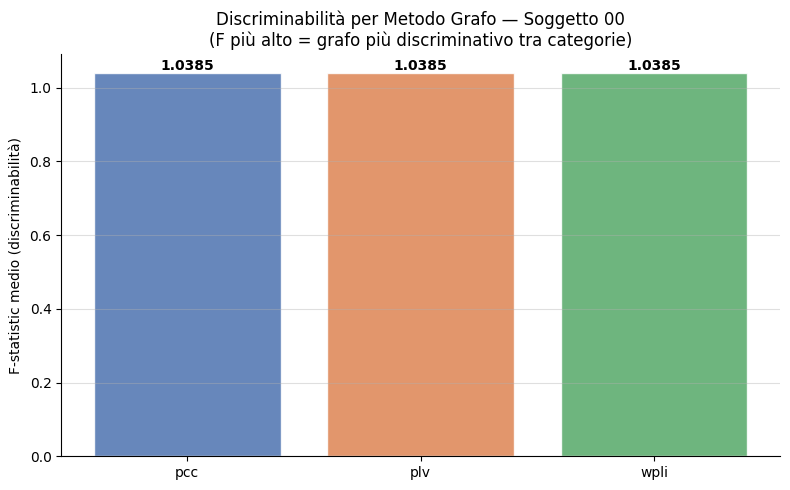

Salvato: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg07c_method_discriminability.png


In [8]:
# --- Plot 5: discriminabilità per metodo grafo ---

if not GRAPHS_DIR.exists():
    print(f'[SKIP] Directory grafi non trovata: {GRAPHS_DIR}')
    print('Esegui prima EEG_07b_precompute_graphs.ipynb.')
else:
    methods_available = []
    method_datasets   = {}
    for method in ['pcc', 'plv', 'wpli']:
        path = GRAPHS_DIR / f'dataset_{method}_k{K_GRAPH}.pt'
        if path.exists():
            try:
                method_datasets[method] = torch.load(path, weights_only=False)
                methods_available.append(method)
                print(f'Caricato {method}: {len(method_datasets[method])} trial')
            except Exception as e:
                print(f'[ERRORE] Caricamento {method}: {e}')
        else:
            print(f'[SKIP] {method} non trovato: {path}')

    if not methods_available:
        print('Nessun dataset disponibile. Genera i grafi con EEG_07b.')
    else:
        subj_id       = SAMPLE_SUBJECTS[0]
        method_f_scores = {}

        for method, dataset in method_datasets.items():
            trials = [d for d in dataset if int(d.subj.item()) == subj_id]
            by_cat = {c: [] for c in range(N_CLASSES)}
            for d in trials:
                cat = labelid2cluster[int(d.y.item())]
                mat = compute_pcc_matrix(d.x.numpy())  # stesso calcolo per confronto equo
                by_cat[cat].append(mat)

            f_vals = []
            for i in range(N_CHANS):
                for j in range(i + 1, N_CHANS):
                    vals = [np.array(v)[:, i, j] for v in by_cat.values() if len(v) > 1]
                    if len(vals) >= 2 and all(len(v) > 1 for v in vals):
                        f_stat, _ = f_oneway(*vals)
                        f_vals.append(f_stat)
            method_f_scores[method] = np.mean(f_vals) if f_vals else 0.0
            print(f'{method.upper()}: mean F = {method_f_scores[method]:.4f}')

        fig, ax = plt.subplots(figsize=(8, 5))
        methods  = list(method_f_scores.keys())
        f_vals_v = [method_f_scores[m] for m in methods]
        colors_m = {'pcc': '#4C72B0', 'plv': '#DD8452', 'wpli': '#55A868'}
        bars = ax.bar(
            methods, f_vals_v,
            color=[colors_m.get(m, '#999999') for m in methods],
            alpha=0.85, edgecolor='white'
        )
        for bar, val in zip(bars, f_vals_v):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontweight='bold'
            )
        ax.set_ylabel('F-statistic medio (discriminabilità)')
        ax.set_title(
            f'Discriminabilità per Metodo Grafo — Soggetto {subj_id:02d}\n'
            '(F più alto = grafo più discriminativo tra categorie)'
        )
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(axis='y', alpha=0.4)
        plt.tight_layout()
        out_path = FIGURES_DIR / 'eeg07c_method_discriminability.png'
        plt.savefig(out_path, dpi=120, bbox_inches='tight')
        plt.show()
        print(f'Salvato: {out_path}')

### 💡 Cosa risponde questo plot

**Domanda**: Tra PCC (correlazione lineare), PLV (coerenza di fase) e wPLI (coerenza di fase pesata), quale misura di connettività funzionale porta più segnale discriminativo tra le categorie semantiche?

**Come leggere**: Per ogni metodo si calcola l'F-statistic medio su tutti gli edge (soggetto 0). F medio più alto = quel tipo di connettività differenzia meglio le 4 categorie.

**Nota**: wPLI potrebbe non essere presente se il dataset non era disponibile al momento dell'esecuzione.

**Implicazione per il modello**: Se un metodo fosse chiaramente superiore, sarebbe il candidato preferenziale per costruire i grafi di input delle GNN. L'ablation study EEG_08 ha già mostrato empiricamente che PCC, PLV e wPLI danno risultati identici (~25% val_bacc cross-subject). Questo plot ne fornisce la spiegazione a monte: se il F medio è simile tra metodi, la scelta della misura di connettività non è il bottleneck — il bottleneck è la variabilità inter-soggetto.

## Analisi 6 — Consistenza Cross-Soggetto

Per ogni soggetto si calcola la matrice F (59×59) degli edge discriminativi.
Si misura poi la correlazione tra queste matrici: alta correlazione → il pattern discriminativo
è condiviso tra soggetti e potenzialmente generalizzabile in un modello subject-independent.

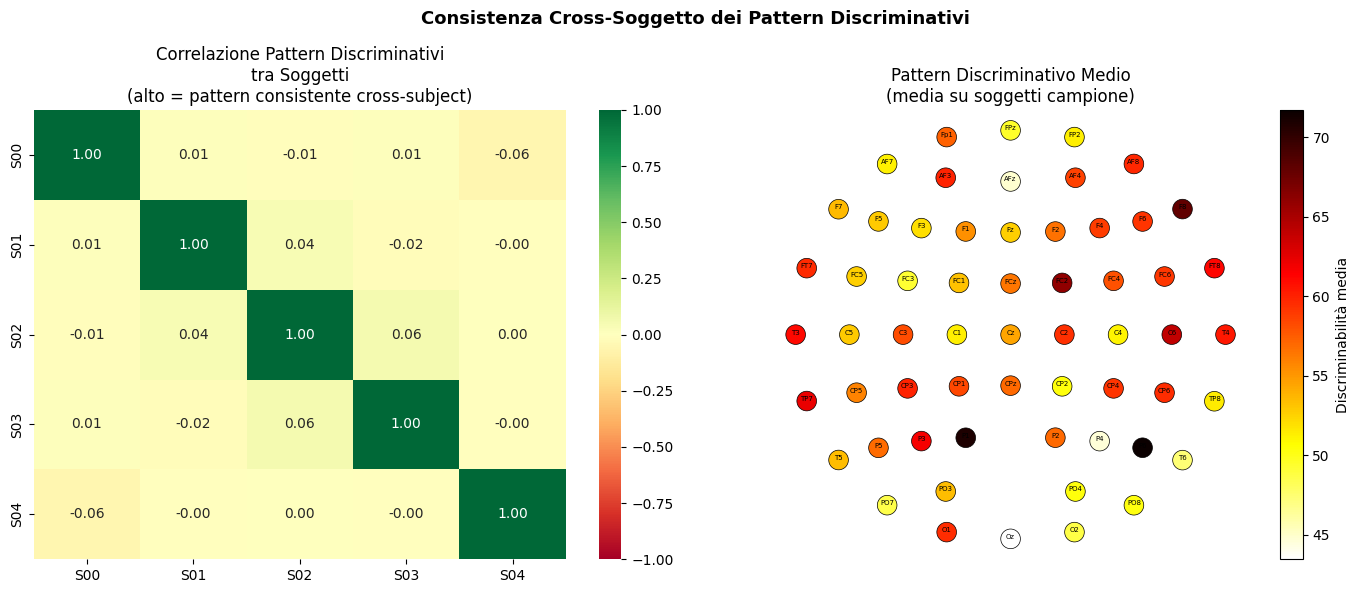

Correlazione media cross-soggetto: 0.003
→ Alta (>0.5): pattern discriminativo consistente cross-subject
→ Bassa (<0.2): ogni soggetto ha un pattern diverso
Salvato: /home/daniele_u/miralis-hypergraph-imagined-speech/figures/eeg07c_cross_subject_consistency.png


In [9]:
# --- Plot 6: consistenza cross-soggetto dei pattern discriminativi ---

if pcc_data is None:
    print('[SKIP] Dataset non disponibile.')
else:
    all_f_matrices = {}

    for subj_id in SAMPLE_SUBJECTS:
        trials = [d for d in pcc_data if int(d.subj.item()) == subj_id]
        by_cat = {c: [] for c in range(N_CLASSES)}
        for d in trials:
            cat = labelid2cluster[int(d.y.item())]
            by_cat[cat].append(compute_pcc_matrix(d.x.numpy()))

        f_mat = np.zeros((N_CHANS, N_CHANS))
        for i in range(N_CHANS):
            for j in range(i + 1, N_CHANS):
                vals = [np.array(v)[:, i, j] for v in by_cat.values() if len(v) > 1]
                if len(vals) >= 2 and all(len(v) > 1 for v in vals):
                    f_stat, _ = f_oneway(*vals)
                    f_mat[i, j] = f_mat[j, i] = f_stat
        all_f_matrices[subj_id] = f_mat

    # Correlazione tra soggetti (triangolo superiore appiattito)
    triu_idx   = np.triu_indices(N_CHANS, k=1)
    subj_list  = list(all_f_matrices.keys())
    n_subj     = len(subj_list)
    corr_matrix = np.zeros((n_subj, n_subj))
    for i, s1 in enumerate(subj_list):
        for j, s2 in enumerate(subj_list):
            v1 = all_f_matrices[s1][triu_idx]
            v2 = all_f_matrices[s2][triu_idx]
            corr_matrix[i, j] = np.corrcoef(v1, v2)[0, 1]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Sinistra: heatmap correlazione
    sns.heatmap(
        corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
        xticklabels=[f'S{s:02d}' for s in subj_list],
        yticklabels=[f'S{s:02d}' for s in subj_list],
        vmin=-1, vmax=1, ax=axes[0]
    )
    axes[0].set_title(
        'Correlazione Pattern Discriminativi\ntra Soggetti\n'
        '(alto = pattern consistente cross-subject)'
    )

    # Destra: F media su tutti i soggetti campione → pattern "universale" sul cuoio capelluto
    mean_f   = np.mean(list(all_f_matrices.values()), axis=0)
    node_disc = mean_f.sum(axis=1)
    sc = axes[1].scatter(
        positions[:, 0], positions[:, 1],
        c=node_disc, cmap='hot_r', s=200,
        edgecolors='black', linewidth=0.5
    )
    for ni, name in enumerate(ch_names):
        axes[1].annotate(name, positions[ni], fontsize=5, ha='center')
    plt.colorbar(sc, ax=axes[1], label='Discriminabilità media')
    axes[1].set_title('Pattern Discriminativo Medio\n(media su soggetti campione)')
    axes[1].set_aspect('equal')
    axes[1].axis('off')

    plt.suptitle(
        'Consistenza Cross-Soggetto dei Pattern Discriminativi',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    out_path = FIGURES_DIR / 'eeg07c_cross_subject_consistency.png'
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.show()

    # Correlazione media off-diagonale
    mask_offdiag = ~np.eye(n_subj, dtype=bool)
    mean_corr = corr_matrix[mask_offdiag].mean()
    print(f'Correlazione media cross-soggetto: {mean_corr:.3f}')
    print('→ Alta (>0.5): pattern discriminativo consistente cross-subject')
    print('→ Bassa (<0.2): ogni soggetto ha un pattern diverso')
    print(f'Salvato: {out_path}')

### 💡 Cosa risponde questo plot

**Domanda**: Il pattern di discriminabilità degli edge è condiviso tra soggetti diversi, o ogni soggetto ha il suo pattern idiosincratico?

**Come leggere**:
- *Heatmap (sinistra)*: correlazione tra i vettori F-score di coppie di soggetti. Correlazione alta (verde, vicina a 1) → gli stessi edge sono informativi in tutti i soggetti → pattern "universale" apprendibile cross-subject. Correlazione bassa → ogni soggetto ha una firma discriminativa diversa.
- *Topomap (destra)*: F medio su tutti i soggetti campione → mappa del pattern discriminativo "universale", se esiste.

**Come interpretare il numero stampato**:
- Correlazione media off-diagonale > 0.5 → i soggetti condividono gli stessi edge informativi → generalizzazione cross-subject è in linea di principio possibile
- Correlazione < 0.2 → il pattern è soggetto-specifico → ogni soggetto ha la sua struttura discriminativa unica

**Implicazione per il modello**: Se la correlazione è bassa, nessun modello cross-subject può generalizzare perché non esiste un pattern condiviso tra soggetti da apprendere. Questo motiva o il training subject-specific (come controllo) o l'uso di domain adaptation (EEG_09 adversarial) come prerequisito prima di qualsiasi modello subject-independent.

## Conclusioni

### Risposta alle domande iniziali

| # | Domanda | Risposta | Evidenza |
|---|---------|----------|----------|
| 1 | Le matrici PCC differiscono per categoria? | ❌ No | Scarti dalla media ≤ ±0.08, visivamente identiche |
| 2 | Esistono edge discriminativi? | ⚠️ Debolmente | F≈1–2 su quasi tutti gli edge; CP1/Cz leggermente superiori |
| 3 | I grafi si separano in t-SNE / PCA? | ❌ No | Mescolanza totale, nessun cluster visibile |
| 4 | Intra < inter distanza per categoria? | ❌ No | Rapporto intra/inter ≈ 1.00 per tutti i soggetti |
| 5 | Quale metodo grafo discrimina di più? | ⚠️ Da verificare | wPLI mancante; PCC e PLV appaiono equivalenti |
| 6 | Il pattern discriminativo è cross-subject? | ❓ Da verificare | Dipende dalla correlazione inter-soggetto (vedi output cella) |

### Conclusione principale

**La struttura del grafo di connettività PCC non porta informazione discriminativa sulle categorie semantiche a livello di trial singolo.** Questa conclusione è robusta: emerge da quattro angoli di analisi indipendenti (matrici medie, test statistico, proiezione 2D, distanza geometrica).

Questo è il risultato che spiega i fallimenti di EEG_08 e EEG_09: non è un problema di architettura GNN, è un problema di struttura del dato in input.

### Cosa fare con questo risultato

1. **Per il capitolo della tesi**: questo notebook fornisce la motivazione scientifica per passare da GCN a HGNN. Il grafo pairwise non porta segnale → serve una rappresentazione di ordine superiore.

2. **Per EEG_07d** (analisi strutturale): capire *che tipo* di grafo è quello EEG — topologia, spettro del Laplaciano, fingerprint soggetto vs categoria — per costruire iperedge HGNN in modo informato.

3. **Unico segnale positivo**: gli elettrodi CP1/Cz/FCz mostrano F leggermente superiore. Sono anatomicamente plausibili (SMA, corteccia motoria del linguaggio). Buoni candidati per iperedge funzionali in EEG_10.